In [1]:
#HASINI V
#BL.SC.U4CSE24221
#ML LAB 2

In [14]:
#A1.
import pandas as pd
import numpy as np
path = r"C:\Users\pc\Desktop\COLLEGE\SEM 5\ML\Lab Session Data (1).xlsx"
df = pd.read_excel(path, sheet_name="Purchase data")
X = df[["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]]
y = df["Payment (Rs)"]
#1. 3 dimensionality
#2. 10
#3. 3 (linearly independent rows or columns)
#4. 
A = X.to_numpy()

rank = np.linalg.matrix_rank(A)

print("Rank of Feature Matrix:", rank)
#5.
A = X.to_numpy()
y = y.to_numpy()

A_pinv = np.linalg.pinv(A)

cost = A_pinv @ y

print("Cost of Candy      :", cost[0])
print("Cost of Mango      :", cost[1])
print("Cost of Milk Packet:", cost[2])

Rank of Feature Matrix: 3
Cost of Candy      : 0.9999999999999989
Cost of Mango      : 54.99999999999999
Cost of Milk Packet: 18.0


Mean = 1560.6634538152612
Variance = 58496.49239931618
Mean = 1560.6634538152612
Variance = 58496.49239931616
Average time for NumPy Mean = 0.00011692047119140624
Average time for User Mean = 3.821849822998047e-05
Average time for NumPy Variance = 0.00011332035064697266
Average time for User Variance = 0.00023326873779296874
Wednesday Sample Mean = nan
Population Mean = 1560.6634538152612
April Sample Mean = 1698.9526315789474
Population Mean = 1560.6634538152612
Probability of Loss = 0.4979919678714859
Probability of Profit on Wednesday = 0.42
Conditional Probability = 0.42


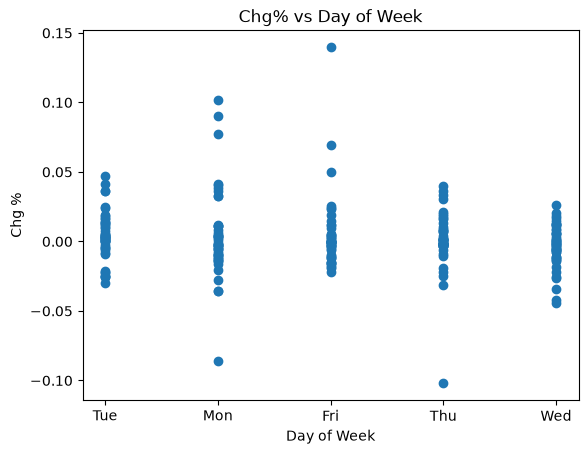

In [18]:
#A3.
import pandas as pd
import numpy as np

path = r"C:\Users\pc\Desktop\COLLEGE\SEM 5\ML\Lab Session Data (1).xlsx"

df = pd.read_excel(path, sheet_name="IRCTC Stock Price")

df.head()
#1.
price = df["Price"]

mean = np.mean(price)
variance = np.var(price)

print("Mean =", mean)
print("Variance =", variance)
#2.
def my_mean(data):
    return sum(data) / len(data)

def my_variance(data):
    m = my_mean(data)
    s = 0
    for x in data:
        s += (x - m) ** 2
    return s / len(data)

print("Mean =", my_mean(price))
print("Variance =", my_variance(price))
#3.
import time

# NumPy Mean
start = time.time()
for i in range(10):
    np.mean(price)
end = time.time()

print("Average time for NumPy Mean =", (end-start)/10)

# User Mean
start = time.time()
for i in range(10):
    my_mean(price)
end = time.time()

print("Average time for User Mean =", (end-start)/10)
# NumPy Variance
start = time.time()
for i in range(10):
    np.var(price)
end = time.time()

print("Average time for NumPy Variance =", (end-start)/10)

# User Variance
start = time.time()
for i in range(10):
    my_variance(price)
end = time.time()

print("Average time for User Variance =", (end-start)/10)
#4. 
wednesday = df[df["Day"] == "Wednesday"]

sample_mean = wednesday["Price"].mean()

print("Wednesday Sample Mean =", sample_mean)
print("Population Mean =", price.mean())
#5. 
april = df[df["Month"] == "Apr"]

sample_mean = april["Price"].mean()

print("April Sample Mean =", sample_mean)
print("Population Mean =", price.mean())
#6.
loss = df["Chg%"].apply(lambda x: x < 0)

probability = loss.sum() / len(df)

print("Probability of Loss =", probability)
#7.
wednesday = df[df["Day"].str.strip().str.lower() == "wed"]

profit = (wednesday["Chg%"] > 0).sum()

probability = profit / len(wednesday)

print("Probability of Profit on Wednesday =", probability)
#8.
wednesday = df[df["Day"].str.strip().str.lower() == "wed"]

conditional_probability = (wednesday["Chg%"] > 0).sum() / len(wednesday)

print("Conditional Probability =", conditional_probability)
#9.
import matplotlib.pyplot as plt

plt.scatter(df["Day"], df["Chg%"])

plt.xlabel("Day of Week")
plt.ylabel("Chg %")
plt.title("Chg% vs Day of Week")

plt.show()

In [19]:
#A4.
import pandas as pd
import numpy as np

path = r"C:\Users\pc\Desktop\COLLEGE\SEM 5\ML\Lab Session Data (1).xlsx"

df = pd.read_excel(path, sheet_name="thyroid0387_UCI")
#1. 
print(df.dtypes)
#Categorical and numerical both
#2.
#norminal attributes is one hot encoding
#ordinal attributes is label encoding
#3.
print(df.describe())
#4.
print(df.isnull().sum())
#5.
numeric = df.select_dtypes(include=np.number)

Q1 = numeric.quantile(0.25)
Q3 = numeric.quantile(0.75)

IQR = Q3 - Q1

outliers = ((numeric < (Q1 - 1.5 * IQR)) | (numeric > (Q3 + 1.5 * IQR)))

print(outliers.sum())
#6.
numeric = df.select_dtypes(include=np.number)

print("Mean")
print(numeric.mean())

print("\nVariance")
print(numeric.var())

print("\nStandard Deviation")
print(numeric.std())

Record ID                     int64
age                           int64
sex                             str
on thyroxine                    str
query on thyroxine              str
on antithyroid medication       str
sick                            str
pregnant                        str
thyroid surgery                 str
I131 treatment                  str
query hypothyroid               str
query hyperthyroid              str
lithium                         str
goitre                          str
tumor                           str
hypopituitary                   str
psych                           str
TSH measured                    str
TSH                          object
T3 measured                     str
T3                           object
TT4 measured                    str
TT4                          object
T4U measured                    str
T4U                          object
FTI measured                    str
FTI                          object
TBG measured                

In [23]:
#A5.
v1 = df.iloc[0]
v2 = df.iloc[1]
# Select columns having only 't' and 'f'
binary = []

for col in df.columns:
    values = set(df[col].dropna().unique())
    if values.issubset({'t', 'f'}):
        binary.append(col)

print("Binary Columns:")
print(binary)

# Take first two records
b1 = df.loc[0, binary]
b2 = df.loc[1, binary]

# Calculate f11, f10, f01, f00
f11 = ((b1 == 't') & (b2 == 't')).sum()
f10 = ((b1 == 't') & (b2 == 'f')).sum()
f01 = ((b1 == 'f') & (b2 == 't')).sum()
f00 = ((b1 == 'f') & (b2 == 'f')).sum()

# Calculate JC and SMC
jc = f11 / (f11 + f10 + f01)
smc = (f11 + f00) / (f11 + f10 + f01 + f00)

print("f11 =", f11)
print("f10 =", f10)
print("f01 =", f01)
print("f00 =", f00)
print("Jaccard Coefficient =", jc)
print("Simple Matching Coefficient =", smc)

#Jaccard coefficient considers only positive matches and simple matching coefficient considers both positive and negative matches. That is why simple matching coefficient is greater than jaccard coefficient.


Binary Columns:
['on thyroxine', 'query on thyroxine', 'on antithyroid medication', 'sick', 'pregnant', 'thyroid surgery', 'I131 treatment', 'query hypothyroid', 'query hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH measured', 'T3 measured', 'TT4 measured', 'T4U measured', 'FTI measured', 'TBG measured']
f11 = 1
f10 = 1
f01 = 2
f00 = 16
Jaccard Coefficient = 0.25
Simple Matching Coefficient = 0.85


In [27]:
#A6.
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Convert all categorical columns into numbers
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Take the first two observation vectors
A = df_encoded.iloc[0].values
B = df_encoded.iloc[1].values

# Calculate Cosine Similarity
cosine_similarity = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

print("Cosine Similarity =", cosine_similarity)

#cosine similarity lies between 0 and 1. If value closer to 1, then 2 vectors are more similar.

Cosine Similarity = 0.8195598934963835


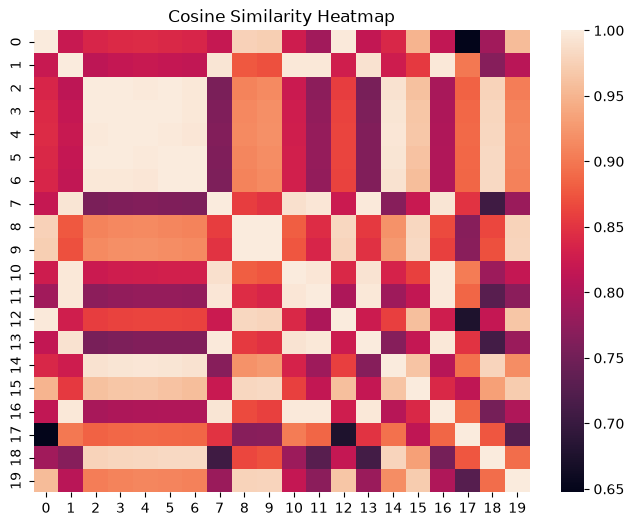

In [33]:
#A7.
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Take the first 20 observations
data = df_encoded.iloc[:20]

# Cosine Similarity Matrix
cos_matrix = np.zeros((20, 20))

for i in range(20):
    for j in range(20):
        a = data.iloc[i].values
        b = data.iloc[j].values
        cos_matrix[i][j] = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Plot Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cos_matrix, annot=False)

plt.title("Cosine Similarity Heatmap")
plt.show()

In [34]:
#A8.
import pandas as pd
import numpy as np

df_imputed = df.copy()

# Fill numeric columns
for col in df_imputed.select_dtypes(include=np.number).columns:
    if df_imputed[col].isnull().sum() > 0:
        Q1 = df_imputed[col].quantile(0.25)
        Q3 = df_imputed[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Use median if outliers are present
        if ((df_imputed[col] < lower) | (df_imputed[col] > upper)).any():
            df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
        else:
            df_imputed[col].fillna(df_imputed[col].mean(), inplace=True)

# Fill categorical columns using mode
for col in df_imputed.select_dtypes(exclude=np.number).columns:
    if df_imputed[col].isnull().sum() > 0:
        df_imputed[col].fillna(df_imputed[col].mode()[0], inplace=True)

print(df_imputed.isnull().sum())

Record ID                    0
age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
TBG                          0
referral source              0
Condition                    0
dtype: int64


In [35]:
#A9.
from sklearn.preprocessing import MinMaxScaler

df_normalized = df_imputed.copy()

numeric_cols = df_normalized.select_dtypes(include=np.number).columns

scaler = MinMaxScaler()

df_normalized[numeric_cols] = scaler.fit_transform(df_normalized[numeric_cols])

print(df_normalized.head())

      Record ID       age sex on thyroxine query on thyroxine  \
0  0.000000e+00  0.000427   F            f                  f   
1  3.410871e-08  0.000427   F            f                  f   
2  9.891527e-07  0.000610   F            f                  f   
3  6.934301e-05  0.000534   F            f                  f   
4  6.937712e-05  0.000473   F            f                  f   

  on antithyroid medication sick pregnant thyroid surgery I131 treatment  ...  \
0                         f    f        f               f              f  ...   
1                         f    f        f               f              f  ...   
2                         f    f        f               f              f  ...   
3                         f    f        f               f              f  ...   
4                         f    f        f               f              f  ...   

  TT4 measured  TT4 T4U measured T4U FTI measured FTI TBG measured TBG  \
0            f    ?            f   ?            

In [42]:
# Optional questions
#1.
import pandas as pd

path = r"C:\Users\pc\Desktop\COLLEGE\SEM 5\ML\Lab Session Data (1).xlsx"

purchase = pd.read_excel(path, sheet_name="Purchase data")

# Create two square matrices
square1 = purchase.iloc[:3, :3]
square2 = purchase.iloc[:4, :4]

print("Square Matrix 1")
print(square1)

print("\nSquare Matrix 2")
print(square2)

Square Matrix 1
  Customer  Candies (#)  Mangoes (Kg)
0      C_1           20             6
1      C_2           16             3
2      C_3           27             6

Square Matrix 2
  Customer  Candies (#)  Mangoes (Kg)  Milk Packets (#)
0      C_1           20             6                 2
1      C_2           16             3                 6
2      C_3           27             6                 2
3      C_4           19             1                 2


In [41]:
#2.
sample_df = df.sample(n=20, random_state=42)

print(sample_df)
print(sample_df.dtypes)

print(sample_df.describe())

print(sample_df.isnull().sum())
binary = []

for col in sample_df.columns:
    values = set(sample_df[col].dropna().unique())
    if len(values) == 2:
        binary.append(col)

print(binary)
from sklearn.preprocessing import LabelEncoder
import numpy as np

sample_encoded = sample_df.copy()

for col in sample_encoded.columns:
    sample_encoded[col] = LabelEncoder().fit_transform(sample_encoded[col].astype(str))

A = sample_encoded.iloc[0].values.astype(float)
B = sample_encoded.iloc[1].values.astype(float)

cos = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

print("Cosine Similarity =", cos)

      Record ID  age sex on thyroxine query on thyroxine  \
624   841003032   72   M            f                  f   
6458  860408064   57   F            f                  f   
3128  850612010   82   M            f                  f   
5501  851217005   58   F            f                  f   
9070  870109043   80   M            f                  f   
3298  850626022   28   M            f                  f   
2664  850507059   78   F            f                  f   
5810  860217001   29   F            f                  f   
5504  851217008   82   M            f                  f   
5274  851128092   20   F            f                  f   
8670  861128023   33   F            f                  f   
4192  850904060   87   F            f                  f   
5924  860225003   60   F            f                  f   
4721  851017029   76   F            f                  f   
8604  861121057   64   F            f                  f   
7361  860818016   56   M            f   

In [40]:
#3.
marketing = pd.read_excel(path, sheet_name="marketing_campaign")
print(marketing.dtypes)

print(marketing.describe())

print(marketing.isnull().sum())
binary = []

for col in marketing.columns:
    values = set(marketing[col].dropna().unique())
    if len(values) == 2:
        binary.append(col)

print(binary)
from sklearn.preprocessing import LabelEncoder
import numpy as np

marketing_encoded = marketing.copy()

for col in marketing_encoded.columns:
    marketing_encoded[col] = LabelEncoder().fit_transform(marketing_encoded[col].astype(str))

A = marketing_encoded.iloc[0].values.astype(float)
B = marketing_encoded.iloc[1].values.astype(float)

cos = np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))

print("Cosine Similarity =", cos)
    

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object
                 ID   Year_Birth         Income      Kidhome     Teenhome  \
count   22